I am trying to do some multi-class classification. I was trying to do it in R but it was going very very poorly. Adaboost isn't fun, and fastAdaboost only does binary classification. I would like to find the most relevant classifiers for what restaurants are going to be in each Michelin Ranking

In [1]:
#Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
#Load the full csv
csvPath = "/Users/benjaminfox/Desktop/Data-400-Final-Project/Every_michelin_restaurant_in_the_world.csv"

michelinDataframe = pd.read_csv(csvPath)

In [3]:
#Double checking that the dataframe is in, which it is
michelinDataframe.head()

,Unnamed: 0,Name,Award,Food.Style.1,Food.Style.2,Pricing,Online.Booking.,Take.Away.,Delivery.,Chef,...,Good.Menu.,Green.Star.,Latitude,Longitude,Michelin.URL,Identifier,Scrape.Date,Market,localPrice,usPrice
0,1,La'Shukran,selected,Middle Eastern,NaN,premium,0,0,0,NaN,...,0,NaN,38.907295,-76.999608,/us/en/district-of-columbia/washington-dc/rest...,1216336,2026-03-17,US,50.0,50.0
1,2,Café Riggs,selected,Contemporary,French,premium,1,0,0,NaN,...,0,NaN,38.897556,-77.024263,/us/en/district-of-columbia/washington-dc/rest...,1190829,2026-03-17,US,50.0,50.0
2,3,Xiquet,ONE_STAR,Spanish,NaN,luxury,1,0,0,NaN,...,0,NaN,38.921587,-77.072383,/us/en/district-of-columbia/washington-dc/rest...,1184921,2026-03-17,US,75.0,75.0
3,4,Rooster & Owl,ONE_STAR,Contemporary,Fusion,premium,1,0,0,NaN,...,0,NaN,38.921467,-77.032160,/us/en/district-of-columbia/washington-dc/rest...,1164753,2026-03-17,US,50.0,50.0
4,5,Family Ethiopian,selected,Ethiopian,Regional Cuisine,mid-range,0,0,0,NaN,...,0,NaN,38.909282,-77.024210,/us/en/district-of-columbia/washington-dc/rest...,1195106,2026-03-17,US,25.0,25.0


Ok now I gotta double check for missing values and datatypes.

In [4]:
michelinDataframe.isnull().sum()

Unnamed: 0             0
Name                   0
Award                  0
Food.Style.1           0
Food.Style.2       12359
Pricing                0
Online.Booking.        0
Take.Away.             0
Delivery.              0
Chef               18133
City                   0
Area               14398
Region                 0
Country                0
Country.Code           0
Currency               0
Good.Menu.             0
Green.Star.        18837
Latitude               0
Longitude              0
Michelin.URL           0
Identifier             0
Scrape.Date            0
Market                 0
localPrice             0
usPrice                0
dtype: int64

I gotta drop some columns that are not going to matter to the final thing. Specifically the following:

- Unnamed: 0
- Name
- Identifier
- Michelin.URL
- Identifier
- Scrape.Date
- Market
- localPrice
- usPrice

These are all being droppped because there is either no way they could matter for classification since they'd all be unique, or because the information they hold is covered in other columns

Three data cleaning tasks that I must do before running the classification model. I will list them in order:

1. Drop irrelevant columns
2. Figure out how to deal with the remaining missing values
3. Adjust the datatypes of all columns

In [5]:
#Getting the unwanted columns
unwantedCols = ["Unnamed: 0", "Name", "Area", "Country.Code","Michelin.URL", "Identifier", "Scrape.Date", "Market", "localPrice", "usPrice"]

#Dropping those columns
reducedFrame = michelinDataframe.drop(columns=unwantedCols)

#Looking at the reduced frame
reducedFrame.head()

,Award,Food.Style.1,Food.Style.2,Pricing,Online.Booking.,Take.Away.,Delivery.,Chef,City,Region,Country,Currency,Good.Menu.,Green.Star.,Latitude,Longitude
0,selected,Middle Eastern,NaN,premium,0,0,0,NaN,Washington,District of Columbia,USA,USD,0,NaN,38.907295,-76.999608
1,selected,Contemporary,French,premium,1,0,0,NaN,Washington,District of Columbia,USA,USD,0,NaN,38.897556,-77.024263
2,ONE_STAR,Spanish,NaN,luxury,1,0,0,NaN,Washington,District of Columbia,USA,USD,0,NaN,38.921587,-77.072383
3,ONE_STAR,Contemporary,Fusion,premium,1,0,0,NaN,Washington,District of Columbia,USA,USD,0,NaN,38.921467,-77.032160
4,selected,Ethiopian,Regional Cuisine,mid-range,0,0,0,NaN,Washington,District of Columbia,USA,USD,0,NaN,38.909282,-77.024210


Since all columns containing missing values are still in this reduced dataframe, I will have to address each column separately. 

- Food.Style.2: Replace all NAs with something pointing to its primary. Likely a new label "See Style One"
- Chef: Replace all NAs with "Unlisted," I don't think this'll matter but I didn't think I should drop it cause it could
- Green Star: Replace all NAs with zeroes. 

In [6]:
#For Food.Style.2
reducedFrame["Food.Style.2"].fillna("See Style One", inplace = True)

#For Chef
reducedFrame["Chef"].fillna("Unlisted", inplace = True)

#For Green Star
reducedFrame["Green.Star."].fillna(0, inplace = True)

#Look at the cleaned dataframe
reducedFrame.head()

,Award,Food.Style.1,Food.Style.2,Pricing,Online.Booking.,Take.Away.,Delivery.,Chef,City,Region,Country,Currency,Good.Menu.,Green.Star.,Latitude,Longitude
0,selected,Middle Eastern,See Style One,premium,0,0,0,Unlisted,Washington,District of Columbia,USA,USD,0,0.0,38.907295,-76.999608
1,selected,Contemporary,French,premium,1,0,0,Unlisted,Washington,District of Columbia,USA,USD,0,0.0,38.897556,-77.024263
2,ONE_STAR,Spanish,See Style One,luxury,1,0,0,Unlisted,Washington,District of Columbia,USA,USD,0,0.0,38.921587,-77.072383
3,ONE_STAR,Contemporary,Fusion,premium,1,0,0,Unlisted,Washington,District of Columbia,USA,USD,0,0.0,38.921467,-77.032160
4,selected,Ethiopian,Regional Cuisine,mid-range,0,0,0,Unlisted,Washington,District of Columbia,USA,USD,0,0.0,38.909282,-77.024210


Now to check data types and see what to do with them

In [7]:
reducedFrame.dtypes

Award               object
Food.Style.1        object
Food.Style.2        object
Pricing             object
Online.Booking.      int64
Take.Away.           int64
Delivery.            int64
Chef                object
City                object
Region              object
Country             object
Currency            object
Good.Menu.           int64
Green.Star.        float64
Latitude           float64
Longitude          float64
dtype: object

Okay, this should be pretty cut and dry
- Replace all objects with categories
- Turn Green.Star. into an integer

In [8]:
#Convert objects to categories
objectCols = ["Award", "Food.Style.1", "Food.Style.2", "Pricing", "Chef", "City", "Region", "Country", "Currency"]

reducedFrame[objectCols] = reducedFrame[objectCols].astype("category")

#Convert Green Star to integer
reducedFrame["Green.Star."] = reducedFrame["Green.Star."].astype("int64")

#Double Check Datatypes
reducedFrame.dtypes

Award              category
Food.Style.1       category
Food.Style.2       category
Pricing            category
Online.Booking.       int64
Take.Away.            int64
Delivery.             int64
Chef               category
City               category
Region             category
Country            category
Currency           category
Good.Menu.            int64
Green.Star.           int64
Latitude            float64
Longitude           float64
dtype: object

Now that that's all done

<h1>Doing the actual fucking classification</h1>

We're gonna be doing a ```DecisionTreeClassifier``` and end up onehotencoding those categorical variables so that scikitlearn can actually interpret them

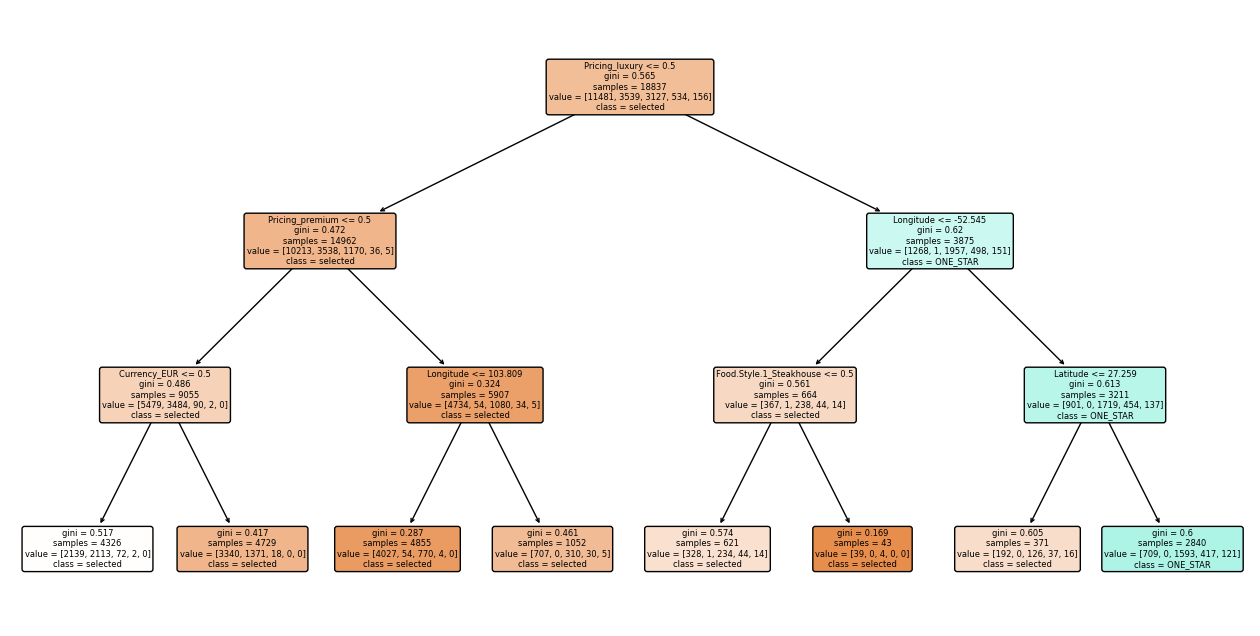

In [9]:
### Pulling from Dick Forrester's DATA 300 notes

#Get the decision tree things
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix


# 1) Select predictors, in this case all columns except for Award
features = ["Food.Style.1", "Food.Style.2", "Pricing", "Online.Booking.", "Take.Away.", "Delivery.", "Chef", "City", "Region", "Country", "Currency", "Good.Menu.", "Green.Star.", "Latitude", "Longitude"]

X = reducedFrame[features].copy()

# 2) One-hot encode categoricals; drop first level for each
X = pd.get_dummies(X, drop_first=True)

# 3) Target: Award (selected, BIB_GOURMAND, ONE_STAR, TWO_STARS, THREE_STARS)
y = reducedFrame["Award"].map({"selected": 1, "BIB_GOURMAND": 2, "ONE_STAR": 3, "TWO_STARS": 4, "THREE_STARS": 5})

# 4) Fit a small, readable tree
clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
clf.fit(X, y)

# 5) Plot the tree
plt.figure(figsize=(16, 8))
plot_tree(
clf,
feature_names=X.columns.to_list(),
class_names=["selected", "BIB_GOURMAND", "ONE_STAR", "TWO_STARS", "THREE_STARS"],
filled=True,
rounded=True,
fontsize=6
)

plt.show()

Okay, so the decision tree actually works, do make sure that the tree reads the column names as a list cause that was what was throwing the error. What I will do now is bag, random forest, and boost to see which give the best results and which variables seem to be doing the most heavy lifting. 

<h2> Random Forest time </h2>

In [31]:
from sklearn.ensemble import RandomForestClassifier

# -----------------------------------------------------------
# Predictors and target
# -----------------------------------------------------------
predictors = ["Food.Style.1", "Food.Style.2", "Pricing", "Online.Booking.", 
              "Take.Away.", "Delivery.", "Chef", "City", "Region", "Country", 
              "Currency", "Good.Menu.", "Green.Star.", "Latitude", "Longitude"]

X_raw = reducedFrame[predictors].copy()

y = reducedFrame["Award"].map({"selected": 1, "BIB_GOURMAND": 2, "ONE_STAR": 3, "TWO_STARS": 4, "THREE_STARS": 5})

# One-hot encode categoricals
X = pd.get_dummies(X_raw, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, train_size=0.8, random_state=8, stratify=y
)


# -----------------------------------------------------------
# Random Forest classifier
# -----------------------------------------------------------
p = X_train.shape[1]
m = int(np.sqrt(p))

print(f"Number of predictors (p): {p}, max_features (m): {m}")

Number of predictors (p): 7668, max_features (m): 87


In [32]:
rf_model = RandomForestClassifier(
n_estimators=500,
max_features=m,
random_state=8
)

In [33]:
#This one is where things are taking forever, at least right now
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_features=87, n_estimators=500, random_state=8)

In [34]:
# Predictions and evaluation
y_pred = rf_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Random Forest Test Accuracy: {test_acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)

Random Forest Test Accuracy: 0.6725
Confusion matrix (rows=true, cols=pred):
[[1967  175  150    5    0]
 [ 452  252    4    0    0]
 [ 298    3  297   22    5]
 [  20    0   70   16    1]
 [   4    0   19    6    2]]


In [35]:
# Feature importances
importances = pd.DataFrame(
{'importance': rf_model.feature_importances_},
index=X.columns
).sort_values(by='importance', ascending=False)
print("\nTop features by importance:")
print(importances.head(10))


Top features by importance:
                             importance
Longitude                      0.127373
Latitude                       0.125741
Pricing_luxury                 0.062440
Pricing_premium                0.043452
Pricing_mid-range              0.040744
Online.Booking.                0.016864
Food.Style.1_Creative          0.012252
Food.Style.2_See Style One     0.010253
Food.Style.1_Modern Cuisine    0.007714
Chef_Unlisted                  0.007288


Huh, that's... interesting. Not the most accurate mind, giving 67% accuracy. Not horrible but like, can boosting do better?

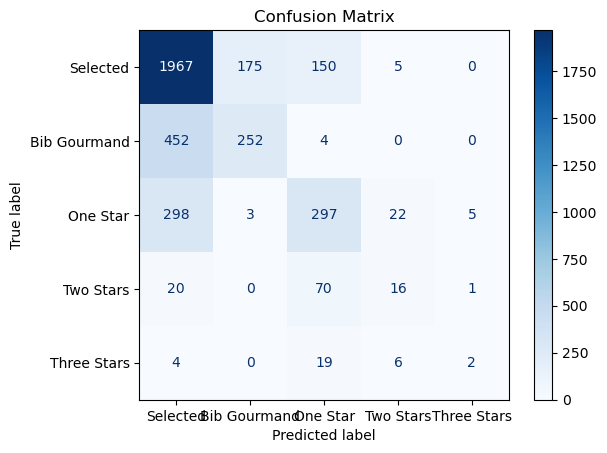

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Selected", "Bib Gourmand", "One Star", "Two Stars", "Three Stars"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

<h2> Boosting </h2>

In [15]:
#Again, pulling directly from Forrester's DATA 300 code
from sklearn.ensemble import GradientBoostingClassifier

# -----------------------------------------------------------
# Gradient Boosting Classifier
# -----------------------------------------------------------
gb_model = GradientBoostingClassifier(
n_estimators=500, # number of boosting stages (trees)
learning_rate=0.01, # step size shrinkage
max_depth=3, # depth of individual regression trees
random_state=8
)

In [16]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, n_estimators=500, random_state=8)

In [17]:
# -----------------------------------------------------------
# Predictions and Evaluation
# -----------------------------------------------------------
y_pred = gb_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Gradient Boosting Test Accuracy: {test_acc:.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(cm)
# -----------------------------------------------------------
# Feature Importances
# -----------------------------------------------------------
importances = pd.DataFrame(
{"importance": gb_model.feature_importances_},
index=X.columns
).sort_values(by="importance", ascending=False)
print("\nTop features by importance:")
print(importances.head(10))

Gradient Boosting Test Accuracy: 0.6791
Confusion matrix (rows=true, cols=pred):
[[2008  159  130    0    0]
 [ 482  226    0    0    0]
 [ 293    7  325    0    0]
 [  15    0   92    0    0]
 [   5    0   26    0    0]]

Top features by importance:
                             importance
Pricing_luxury                 0.405030
Pricing_premium                0.202992
Pricing_mid-range              0.127738
Longitude                      0.080897
Food.Style.1_Creative          0.020042
Currency_EUR                   0.019910
Latitude                       0.017683
Chef_Unlisted                  0.015592
Food.Style.1_Modern Cuisine    0.009193
Food.Style.1_Seafood           0.005139


As both Gradient Boosting and Random Forest had very similar test accuracy, and that said accuracy was around 67% accurate in both settings, we'll try to take that for what it is. Over 50% indicates that these models *can* predict which restaurants are likely to get a specific Michelin ranking, but the elite nature of the second and third michelin star means that they are really hard to predict by comparison. Pricing tends to be a decent indicator, especially with luxury pricing. Exact location also seems to matter, Longitude specifically which I find... curious.

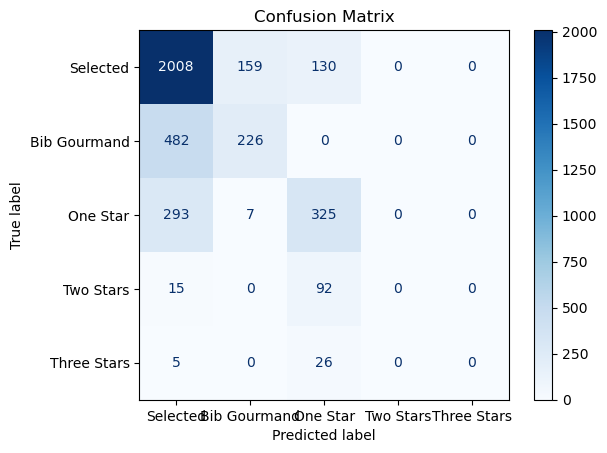

In [30]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Selected", "Bib Gourmand", "One Star", "Two Stars", "Three Stars"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()